In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
df1=pd.read_csv('train_labels.csv')
df2=pd.read_csv('train_values.csv')

In [3]:
df2.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df1.head()

,building_id,damage_grade
0,802906,3
1,28830,2
2,94947,3
3,590882,2
4,201944,3


In [6]:
df1_subset = df1[["building_id", "damage_grade"]]
final_df = pd.merge(df2, df1_subset, on="building_id", how="inner")

In [7]:
final_df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [8]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [9]:
final_df.drop('building_id',inplace=True,axis=True)

In [10]:
final_df.head()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,6,487,12198,2,30,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
1,8,900,2812,2,10,8,7,o,r,n,...,0,0,0,0,0,0,0,0,0,2
2,21,363,8973,2,10,5,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
3,22,418,10694,2,10,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
4,11,131,1488,3,30,8,9,t,r,n,...,0,0,0,0,0,0,0,0,0,3


In [11]:
final_df.describe()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,0.034332,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,0.182081,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


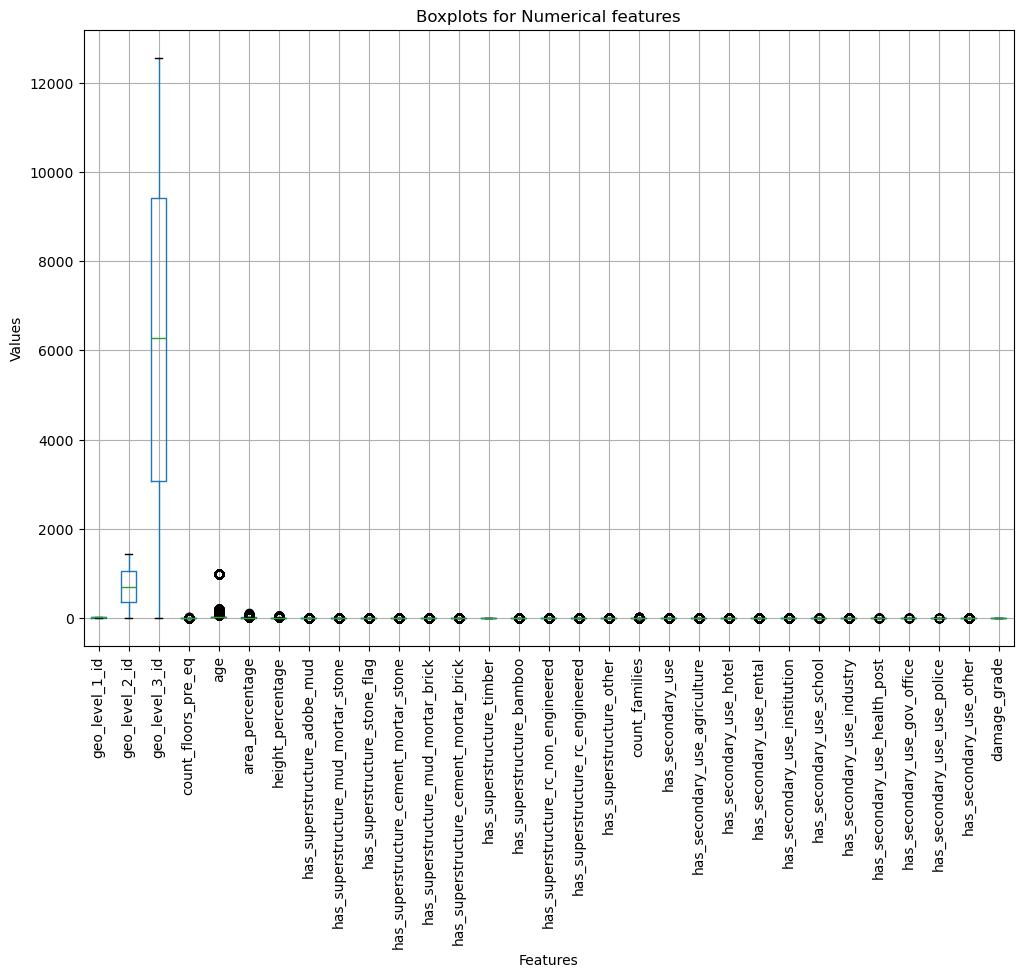

In [15]:
# creating boxplots for numerical features

num_col=final_df.select_dtypes(include=['int']).columns

plt.figure(figsize=(12,8))
final_df[num_col].boxplot()
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Values')
plt.title('Boxplots for Numerical features')
plt.show()

In [17]:
!pip install ydata_profiling

  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached minify_html-0.18.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (18 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached phik-0.12.5-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.6 kB)
  Using cached multimethod-1.12-py3-none-any.whl.metadata (9.6 kB)
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached dacite-1.9.2-py3-none-any.whl.metadata (17 kB)
Using cached ImageHash-4.3.2-py2.py3-none-any.whl (296 kB)
Using cached dacite-1.9.2-py3-none-any.whl (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 7.8 MB/s  0:00:01a 0:00:010:00:01:01m
Using cached multimethod-1.12-py3-none-any.whl (10 kB)
Using cached phik-0.12.5-cp313-cp313-macosx_11_0_arm64.whl (666 kB)
Using cached visions-0.8.1-py3-none-any.whl (105 kB)
Using cached filetype-1.2.0-py2.py3-none-any.whl (19 kB)
Using cached minify_html-0.18.1-cp313-cp313-macosx_11_0_arm64.whl (2.

In [28]:
profile = ProfileReport(final_df,explorative=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████| 39/39 [00:03<00:00, 11.62it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: >

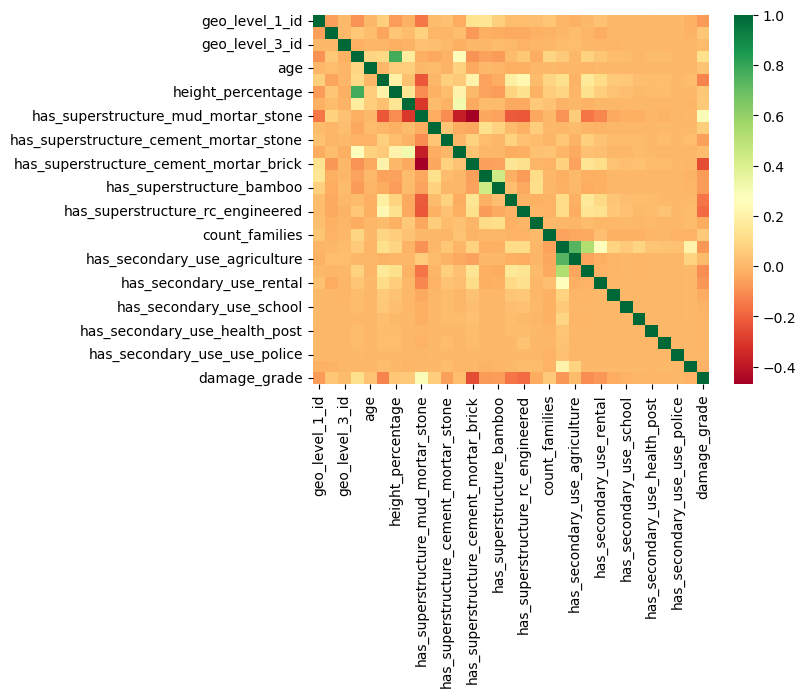

In [35]:
# check correlation via heatmap

plt.plot(figsize=(28,28))
sns.heatmap(final_df.select_dtypes(include=['int']).corr(),cmap="RdYlGn")

In [42]:
for col in ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id']:

    print(col, final_df[col].nunique())

geo_level_1_id 31
geo_level_2_id 1414
geo_level_3_id 11595


In [51]:
X=final_df.drop('damage_grade',axis=1)
y=final_df['damage_grade']

In [54]:
# Frequency encoder for geo level Id columns due to high number of IDs

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

high_occur=['geo_level_1_id','geo_level_2_id','geo_level_3_id']

for col in high_occur:
    freq=X_train[col].value_counts()
    X_train[col]=X_train[col].map(freq)
    X_test[col]=X_test[col].map(freq).fillna(0)

In [74]:
# OneHotEncoder for non-numbered variables

OHE_columns=['land_surface_condition','foundation_type','roof_type','ground_floor_type','other_floor_type','position','legal_ownership_status','plan_configuration']

In [83]:
pass_through=X.select_dtypes(include=['int']).columns

In [128]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer([('OHE columns', OneHotEncoder(), OHE_columns),('Passthrough', 'passthrough', pass_through)])
preprocessor

,transformers,"[('OHE columns', ...), ('Passthrough', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [87]:
## Decision Tree

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
pipeline=Pipeline([('preprocessor',preprocessor),('model',DecisionTreeClassifier())])
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score,classification_report,f1_score
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.50      0.51      0.50      5170
           2       0.71      0.71      0.71     29487
           3       0.62      0.62      0.62     17464

    accuracy                           0.66     52121
   macro avg       0.61      0.61      0.61     52121
weighted avg       0.66      0.66      0.66     52121



In [90]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
rf_pipeline=Pipeline([('preprocessor',preprocessor),('model',RandomForestClassifier())])
rf_pipeline.fit(X_train,y_train)
rf_y_pred=rf_pipeline.predict(X_test)

In [91]:
from sklearn.metrics import accuracy_score,classification_report,f1_score
print(classification_report(y_test,rf_y_pred))

              precision    recall  f1-score   support

           1       0.67      0.48      0.56      5170
           2       0.72      0.82      0.77     29487
           3       0.72      0.61      0.66     17464

    accuracy                           0.72     52121
   macro avg       0.70      0.64      0.66     52121
weighted avg       0.72      0.72      0.71     52121



In [96]:
# Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier
gf_pipeline=Pipeline([('preprocessor',preprocessor),('model',GradientBoostingClassifier())])
gf_pipeline.fit(X_train,y_train)
gf_y_pred=gf_pipeline.predict(X_test)

In [97]:
print(classification_report(y_test,gf_y_pred))

              precision    recall  f1-score   support

           1       0.67      0.36      0.47      5170
           2       0.67      0.85      0.75     29487
           3       0.71      0.49      0.58     17464

    accuracy                           0.68     52121
   macro avg       0.68      0.57      0.60     52121
weighted avg       0.69      0.68      0.67     52121



In [99]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.7 MB/s  0:00:00m 10.1 MB/s eta 0:00:01


In [101]:
# XG Boosting

from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)

y_test_xgb = le.transform(y_test)
xg_pipeline=Pipeline([('preprocessor',preprocessor),('model',XGBClassifier())])
xg_pipeline.fit(X_train,y_train_xgb)
xg_y_pred=xg_pipeline.predict(X_test)

In [103]:
y_pred_original = le.inverse_transform(xg_y_pred)

In [105]:
print(classification_report(y_test,y_pred_original))

              precision    recall  f1-score   support

           1       0.71      0.46      0.56      5170
           2       0.72      0.85      0.78     29487
           3       0.74      0.59      0.66     17464

    accuracy                           0.72     52121
   macro avg       0.72      0.63      0.67     52121
weighted avg       0.73      0.72      0.72     52121



In [111]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = pd.DataFrame({ "Model": ["Decision Tree","Random Forest","Gradient Boosting","XGBoost"],"Accuracy": [accuracy_score(y_test,y_pred),
accuracy_score(y_test, rf_y_pred),accuracy_score(y_test, gf_y_pred),accuracy_score(y_test, y_pred_original)], "Precision": [precision_score(y_test, y_pred, average="weighted"),
precision_score(y_test, rf_y_pred, average="weighted"),precision_score(y_test, gf_y_pred, average="weighted"),precision_score(y_test, y_pred_original, average="weighted")
],"Recall": [recall_score(y_test, y_pred, average="weighted"),recall_score(y_test, rf_y_pred, average="weighted"),recall_score(y_test, gf_y_pred, average="weighted"),
recall_score(y_test, y_pred_original, average="weighted") ],"F1 Score": [f1_score(y_test, y_pred, average="weighted"),f1_score(y_test, rf_y_pred, average="weighted"),
f1_score(y_test, gf_y_pred, average="weighted"),f1_score(y_test, y_pred_original, average="weighted")]})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.656952,0.657260,0.656952,0.657099
1,Random Forest,0.718444,0.716507,0.718444,0.712859
2,Gradient Boosting,0.681702,0.685033,0.681702,0.665919
3,XGBoost,0.724104,0.725568,0.724104,0.716059


In [119]:
# hyperparameters tuning for XGBOOST

from sklearn.model_selection import GridSearchCV
param_grid={'model__n_estimators':[100,200,300],'model__learning_rate':[0.01,0.05,0.1],'model__max_depth':[3,5,7],'model__subsample':[0.8,1.0],'model__colsample_bytree':[0.8,1.0]}
grid=GridSearchCV(estimator=xg_pipeline,param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1,verbose=2)
grid.fit(X_train,y_train_xgb)
print(grid.best_params_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   0.8s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200, model__subsample=0.8; total time=   0.7s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=200, model__subsample=1.0; total time=   0.7s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=300, model__subsample=1.0; total time=   0.8s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=5, model__n_estimators=100, model__subsample=1.0; total time=   0.6s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.01, model__max_depth=5, model__n_estimators=200, model__subsample=0.8; total time=   0.7s
[CV] END model__colsample_bytre

In [120]:
print(hasattr(grid, "best_params_"))
print(grid.best_params_)
print(grid.best_score_)

True
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__subsample': 0.8}
0.7317536454336148


In [129]:
best_model=grid.best_estimator_
y_best_pred = grid.best_estimator_.predict(X_test)
print(classification_report(y_test_xgb, y_best_pred))

              precision    recall  f1-score   support

           0       0.72      0.49      0.58      5170
           1       0.73      0.85      0.78     29487
           2       0.75      0.60      0.67     17464

    accuracy                           0.73     52121
   macro avg       0.73      0.65      0.68     52121
weighted avg       0.73      0.73      0.73     52121



In [133]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=1.0,
        random_state=42
    ))
])

best_pipeline.fit(X_train, y_train_xgb)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('OHE columns', ...), ('Passthrough', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [134]:
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [136]:
importance = pd.Series(

    best_pipeline.named_steps['model'].feature_importances_,

    index=feature_names

).sort_values(ascending=False)

print(importance.head(10))

OHE columns__foundation_type_r                         0.315735
OHE columns__ground_floor_type_v                       0.088723
Passthrough__has_superstructure_mud_mortar_stone       0.063482
OHE columns__foundation_type_i                         0.046336
Passthrough__geo_level_1_id                            0.041897
Passthrough__has_superstructure_cement_mortar_brick    0.037299
OHE columns__other_floor_type_q                        0.028540
OHE columns__roof_type_x                               0.020897
Passthrough__has_superstructure_stone_flag             0.018740
OHE columns__foundation_type_w                         0.015046
dtype: float32


In [137]:
grid.best_params_

{'model__colsample_bytree': 1.0,
 'model__learning_rate': 0.1,
 'model__max_depth': 7,
 'model__n_estimators': 300,
 'model__subsample': 0.8}

In [138]:
# Suggestions to the Seismologists to avoid earthquake event leading  to significant damage in many buildings

'''Based on the above machine learning importance analysis, it can be said that the foundation type that's used has the highest impact on earthquake damage. So it is suggested use better standards for foundation type. 

additionally, ground floor type and superstructure has significant impact too. Authorities should consider using stronger quailty materials.'''

"Based on the above machine learning importance analysis, it can be said that the foundation type that's used has the highest impact on earthquake damage. So it is suggested use better standards for foundation type. \n\nadditionally, ground floor type and superstructure has significant impact too. Authorities should consider using stronger quailty materials."

In [139]:
# Model Comparison Report

'''Based on the above results in cell 111, XGBoost produced the best result with an accuracy score of 72.4%. I also used hyperparameter tuning to increase the score to 73% in cell 129'''

'Based on the above results in cell 111, XGBoost produced the best result with an accuracy score of 72.4%. I also used hyperparameter tuning to increase the score to 73% in cell 129'

In [142]:
#Report on Challenges Faced During Data Analysis and Modeling

##1. Handling Categorical Variables

###Challenge:

#The dataset contained several categorical features such as foundation type, roof type, ground floor type, and other structural characteristics. Machine learning algorithms cannot directly process categorical text values.

###Technique Used:

#One-Hot Encoding was applied to categorical variables.

###Reason:

#One-Hot Encoding converts categorical values into numerical representations without assuming any order or ranking between categories. This was suitable because building attributes such as foundation type or roof type do not have a natural numerical relationship.



##2. High Number of Categories in Features

###Challenge:

#Some categorical variables contained multiple unique categories, increasing the number of features after encoding. This could increase model complexity and computational requirements.

###Technique Used:

#Frequency encoding was applied by separating categorical variables for One-Hot Encoding and keeping suitable numerical variables unchanged using passthrough.

###Reason:

#This approach reduced unnecessary transformations while preserving important numerical information. It also allowed tree-based models like XGBoost to efficiently learn relationships from the data.



##3. Feature Selection and Identifying Important Variables

###Challenge:

#The dataset contained 39 original features, making it difficult to determine which variables contributed most to earthquake damage prediction.

###Technique Used:

#Feature importance from the XGBoost model was used.

###Reason:

#Tree-based models can capture nonlinear relationships between features and target variables. Feature importance provided a better understanding of which building characteristics had the greatest influence on predicted damage levels.



##4. Model Performance Optimization

###Challenge:

#Initial model performance was not optimal, and improving accuracy required selecting suitable hyperparameters.

###Technique Used:

#GridSearchCV was used for hyperparameter tuning.

###Reason:

#GridSearchCV systematically tested different combinations of parameters such as number of estimators, learning rate, depth of trees, subsampling, and column sampling. This helped identify the best-performing XGBoost model configuration.



###5. Managing Model Complexity and Training Time

###Challenge:

#Testing multiple hyperparameter combinations significantly increased training time due to the size of the dataset.

###Technique Used:

#A limited but meaningful hyperparameter search space was selected.

###Reason:

#Testing every possible combination would require excessive computational resources. A focused search provided a balance between improving model performance and reducing execution time.



###6. Interpreting Machine Learning Results for Real-World Recommendations

###Challenge:

#Machine learning outputs provide numerical predictions, but the results need to be converted into practical earthquake safety recommendations.

###Technique Used:

#Feature importance analysis was used to identify influential building characteristics.

###Reason:

#The analysis showed that factors such as foundation type, ground floor construction, and building materials strongly influenced damage predictions. These insights can help recommend improvements in earthquake-resistant construction practices.